Esta notebook contiene bloques de código útiles para realizar Q-learning en el entorno "Continuous Mountain Car"

In [2]:
import numpy as np
import gymnasium as gym
import random 

In [3]:
# Cambiar render_mode a rgb_array para entrenar/testear
env_id = 'MountainCarContinuous-v0'
env = gym.make(env_id, render_mode='human')

Observation Space

In [3]:
env.observation_space

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

Action Space

In [4]:
env.action_space

Box(-1.0, 1.0, (1,), float32)

Discretización de los estados

In [4]:
x_space = np.linspace(-1.2, 0.6, 100)
vel_space = np.linspace(-0.07, 0.07, 100)
x_space

array([-1.2       , -1.18181818, -1.16363636, -1.14545455, -1.12727273,
       -1.10909091, -1.09090909, -1.07272727, -1.05454545, -1.03636364,
       -1.01818182, -1.        , -0.98181818, -0.96363636, -0.94545455,
       -0.92727273, -0.90909091, -0.89090909, -0.87272727, -0.85454545,
       -0.83636364, -0.81818182, -0.8       , -0.78181818, -0.76363636,
       -0.74545455, -0.72727273, -0.70909091, -0.69090909, -0.67272727,
       -0.65454545, -0.63636364, -0.61818182, -0.6       , -0.58181818,
       -0.56363636, -0.54545455, -0.52727273, -0.50909091, -0.49090909,
       -0.47272727, -0.45454545, -0.43636364, -0.41818182, -0.4       ,
       -0.38181818, -0.36363636, -0.34545455, -0.32727273, -0.30909091,
       -0.29090909, -0.27272727, -0.25454545, -0.23636364, -0.21818182,
       -0.2       , -0.18181818, -0.16363636, -0.14545455, -0.12727273,
       -0.10909091, -0.09090909, -0.07272727, -0.05454545, -0.03636364,
       -0.01818182,  0.        ,  0.01818182,  0.03636364,  0.05

Obtener el estado a partir de la observación

In [4]:
def get_state(obs):
    x, vel = obs
    x_bin = np.digitize(x, x_space)
    vel_bin = np.digitize(vel, vel_space)
    return x_bin, vel_bin

In [5]:
state = get_state(np.array([-0.4, 0.02]))
state

(np.int64(45), np.int64(64))

Discretización de las acciones

In [5]:
actions = list(np.linspace(-1, 1, 10))
actions

[np.float64(-1.0),
 np.float64(-0.7777777777777778),
 np.float64(-0.5555555555555556),
 np.float64(-0.33333333333333337),
 np.float64(-0.11111111111111116),
 np.float64(0.11111111111111116),
 np.float64(0.33333333333333326),
 np.float64(0.5555555555555554),
 np.float64(0.7777777777777777),
 np.float64(1.0)]

In [7]:
def get_sample_action():
    return random.choice(actions)

Inicilización de la tabla Q

In [8]:
Q = np.zeros((len(x_space) + 1, len(vel_space) + 1, len(actions)))
Q

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

Obtención de la acción a partir de la tabla Q

In [11]:
def optimal_policy(state, Q):
    action = actions[np.argmax(Q[state])]
    return action

Epsilon-Greedy Policy

In [12]:
def epsilon_greedy_policy(state, Q, epsilon=0.1):
    explore = np.random.binomial(1, epsilon)
    if explore:
        action = get_sample_action()
    else:
        action = optimal_policy(state, Q)
        
    return action

In [13]:
# Testear el agente entrenado (sin exploración)
print("\nTesteando agente entrenado...")
from dyna_q_agent import DynaQAgent
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='human')
test_rewards, test_steps = agent.test_agent(env, episodes=3, render=True)
env.close()

print(f"\nPromedio de rewards en testing: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps en testing: {np.mean(test_steps):.2f}")


Testeando agente entrenado...
Modelo cargado desde dyna_agent_trained.npy (Q shape: (101, 101, 20))
Test Episode 1 - Reward: 94.40, Steps: 184, Success: 1
Test Episode 2 - Reward: 94.29, Steps: 310, Success: 1
Test Episode 3 - Reward: 94.61, Steps: 261, Success: 1


ValueError: too many values to unpack (expected 2)

Entrenando agente Q-Learning...
Episode 800/8000 - Avg Reward: -100.57, Steps: 3000
Episode 1600/8000 - Avg Reward: -91.30, Steps: 3000
Episode 2400/8000 - Avg Reward: -82.88, Steps: 3000
Episode 3200/8000 - Avg Reward: -74.96, Steps: 3000
Episode 4000/8000 - Avg Reward: -66.77, Steps: 3000
Episode 4800/8000 - Avg Reward: -58.08, Steps: 3000
Episode 5600/8000 - Avg Reward: -48.78, Steps: 3000
Episode 6400/8000 - Avg Reward: -40.24, Steps: 3000
Episode 7200/8000 - Avg Reward: -31.00, Steps: 3000
Episode 8000/8000 - Avg Reward: -22.04, Steps: 3000


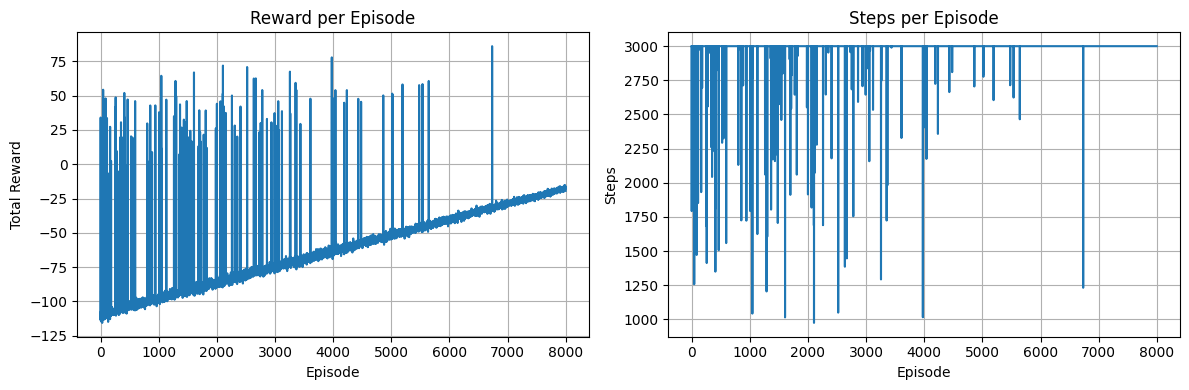

In [6]:
from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.15,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

# Mostrar tasa de éxito en entrenamiento
#train_successes = sum(agent.training_history['successes'])
#print(f"\nÉxitos en entrenamiento: {train_successes}/{len(agent.training_history['successes'])} ({train_successes / len(agent.training_history['successes']) * 100:.1f}%)")

Entrenando agente Dyna-Q...
Episode 500/5000 - Avg Reward: -34.92, Steps: 1000, Success: 0.6%
Episode 1000/5000 - Avg Reward: -31.41, Steps: 655, Success: 1.0%
Episode 1500/5000 - Avg Reward: -22.84, Steps: 1000, Success: 6.8%
Episode 2000/5000 - Avg Reward: -3.76, Steps: 1000, Success: 22.8%
Episode 2500/5000 - Avg Reward: 20.28, Steps: 721, Success: 42.8%
Episode 3000/5000 - Avg Reward: 40.02, Steps: 1000, Success: 59.0%
Episode 3500/5000 - Avg Reward: 52.36, Steps: 589, Success: 69.0%
Episode 4000/5000 - Avg Reward: 67.82, Steps: 376, Success: 82.2%
Episode 4500/5000 - Avg Reward: 77.24, Steps: 234, Success: 89.4%
Episode 5000/5000 - Avg Reward: 88.10, Steps: 174, Success: 98.2%
Modelo guardado en dyna_agent_trained.npy


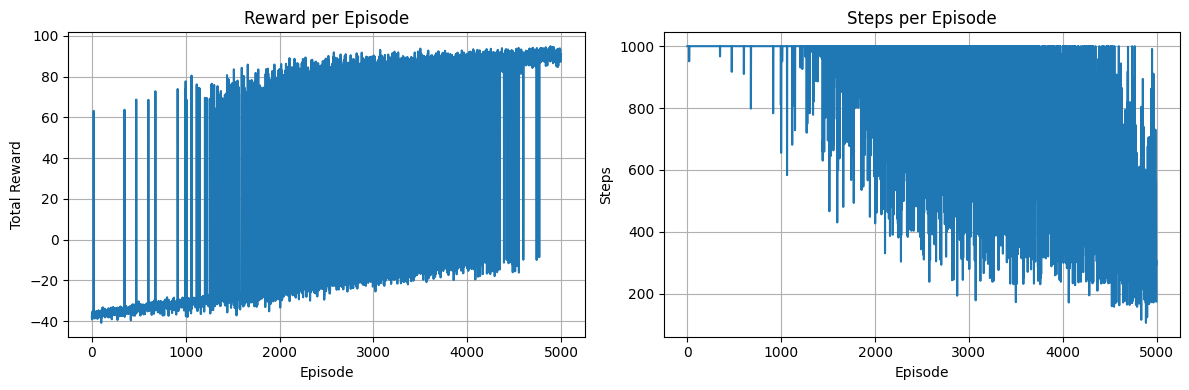

In [6]:
from dyna_q_agent import DynaQAgent

# Crear agente con configuración inicial
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Dyna-Q...")
agent.train_agent(
    env, 
    episodes=5000,
    alpha=0.03,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.2,
    max_steps=1000,
    planning_steps=20
)
env.close()

# Guardar el modelo entrenado
agent.save_model('dyna_agent_trained.npy')

# Visualizar progreso de entrenamiento
agent.plot_training_history()


Continuando entrenamiento desde el modelo guardado...
Modelo cargado desde dyna_agent_trained.npy (Q shape: (101, 101, 20))
Episode 150/1500 - Avg Reward: 90.35, Steps: 97, Success: 98.7%
Episode 300/1500 - Avg Reward: 91.80, Steps: 132, Success: 100.0%
Episode 450/1500 - Avg Reward: 91.42, Steps: 192, Success: 100.0%
Episode 600/1500 - Avg Reward: 92.12, Steps: 131, Success: 100.0%
Episode 750/1500 - Avg Reward: 92.23, Steps: 157, Success: 100.0%
Episode 900/1500 - Avg Reward: 92.94, Steps: 97, Success: 100.0%
Episode 1050/1500 - Avg Reward: 86.96, Steps: 95, Success: 94.7%
Episode 1200/1500 - Avg Reward: 86.29, Steps: 100, Success: 94.0%
Episode 1350/1500 - Avg Reward: 92.61, Steps: 111, Success: 99.3%
Episode 1500/1500 - Avg Reward: 85.28, Steps: 89, Success: 93.3%
Modelo guardado en dyna_agent_trained_v2.npy


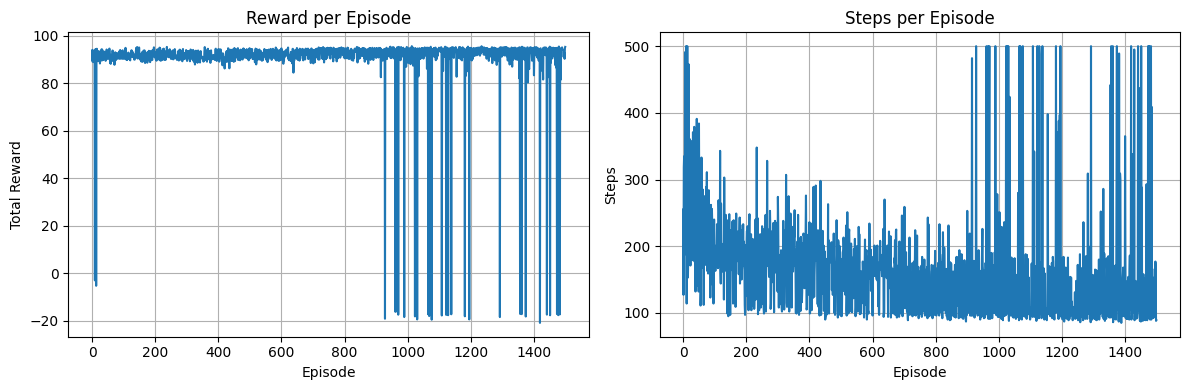

Modelo actualizado guardado en dyna_agent_trained_v2.npy


In [12]:
# Continuar entrenamiento a partir del modelo guardado
from dyna_q_agent import DynaQAgent

print("\nContinuando entrenamiento desde el modelo guardado...")
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
agent.train_agent(
    env,
    episodes=1500,
    alpha=0.03,
    gamma=0.98,
    epsilon_start=0.1,
    epsilon_end=0.05,
    max_steps=500,
    planning_steps=35
)
env.close()

agent.save_model('dyna_agent_trained_v2.npy')
agent.plot_training_history()
print("Modelo actualizado guardado en dyna_agent_trained_v2.npy")

In [12]:
# Diagnóstico rápido del modelo cargado
import numpy as np

from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

print('Q shape:', getattr(agent, 'Q', None).shape if hasattr(agent, 'Q') else 'no Q')
print('Q sum:', np.sum(agent.Q))
print('Q max:', np.max(agent.Q))
print('Non-zero count:', np.count_nonzero(agent.Q))

# Mostrar los valores de Q para el estado inicial
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
obs, _ = env.reset()
state = agent.discretize_state(obs)
print('Initial observation:', obs)
print('Discretized state:', state)
print('Q[state]:', agent.Q[state])

# Acción determinista según la política actual
action = agent.next_action(state, epsilon=0.0, training=False)
print('Selected action (deterministic):', action)
env.close()

Modelo cargado desde dyna_agent_trained.npy
Q shape: (101, 101, 20)
Q sum: 131168101.42945522
Q max: 4190.041559971841
Non-zero count: 113456
Initial observation: [-0.58408296  0.        ]
Discretized state: (np.int64(34), np.int64(50))
Q[state]: [-0.11590209 -0.09593802 -0.07826212 -0.06263247 -0.04938895 -0.03797162
 -0.0294172  -0.02288526 -0.01827912 -0.01695768 -0.016957   -0.01845724
 -0.02281294 -0.02948479 -0.03840363 -0.04951224 -0.06252603 -0.07805158
 -0.09584551 -0.1157675 ]
Selected action (deterministic): 0.05263157894736836
